<a href="https://colab.research.google.com/github/joshuajhchoi/ai2learn/blob/master/house_price_prediction_kr_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 선형 회귀를 이용한 집값 예측

이 노트북에서는 선형 회귀 모델을 사용하여 집값을 예측하는 방법을 알아보겠습니다. 보스턴 주택 데이터셋을 사용하여 다양한 특성(feature)을 기반으로 주택 가격을 예측하는 모델을 구축하고 평가해 보겠습니다.

## 1. 필요한 라이브러리 임포트

In [1]:
# 데이터 처리 및 분석 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 메시지 무시
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정 - 에러 방지를 위해 try-except 사용
try:
    plt.style.use('seaborn')
except:
    print("스타일 설정 에러가 발생했습니다. 기본 스타일을 사용합니다.")

# 한글 폰트 설정 (시스템에 폰트가 있는 경우에만 적용)
try:
    plt.rc('font', family='Malgun Gothic')  # 한글 폰트 설정
    plt.rc('axes', unicode_minus=False)  # 마이너스 기호 깨짐 방지
except:
    print("폰트 설정 에러가 발생했습니다. 기본 폰트를 사용합니다.")

# scikit-learn 라이브러리
from sklearn.datasets import fetch_california_housing  # 캘리포니아 주택 데이터셋
from sklearn.model_selection import train_test_split  # 데이터 분할
from sklearn.linear_model import LinearRegression  # 선형 회귀 모델
from sklearn.metrics import mean_squared_error, r2_score  # 평가 지표
from sklearn.preprocessing import StandardScaler  # 특성 스케일링

스타일 설정 에러가 발생했습니다. 기본 스타일을 사용합니다.


## 2. 데이터 로드 및 탐색

In [2]:
# 캘리포니아 주택 데이터셋 로드
housing = fetch_california_housing()

# 데이터프레임 생성
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['PRICE'] = housing.target

# 데이터셋 기본 정보 확인
print("데이터셋 크기:", df.shape)
print("\n데이터셋 특성:")
print(housing.DESCR)

데이터셋 크기: (20640, 9)

데이터셋 특성:
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S

In [3]:
# 데이터 미리보기
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
# 기술 통계량 확인
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## 3. 데이터 시각화 및 분석

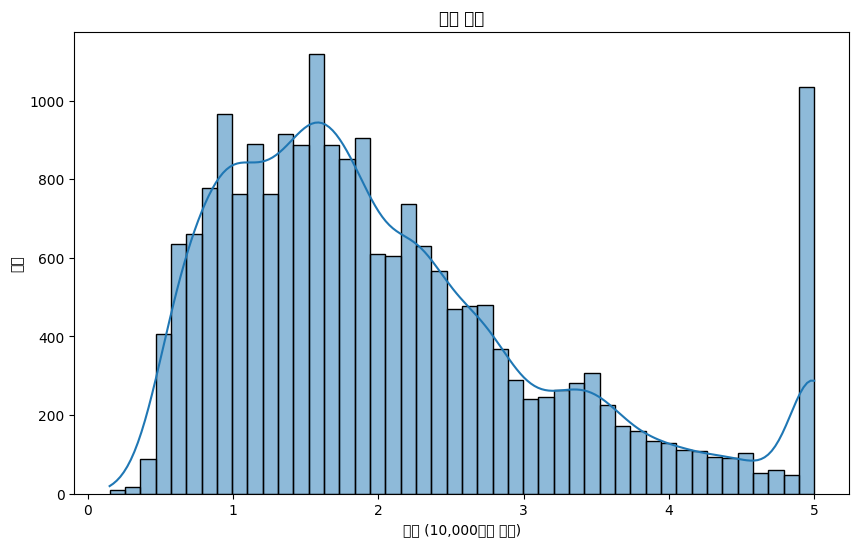

In [5]:
# 타겟 변수(집값) 분포 확인
plt.figure(figsize=(10, 6))
sns.histplot(df['PRICE'], kde=True)
plt.title('집값 분포')
plt.xlabel('집값 (10,000달러 단위)')
plt.ylabel('빈도')
plt.show()

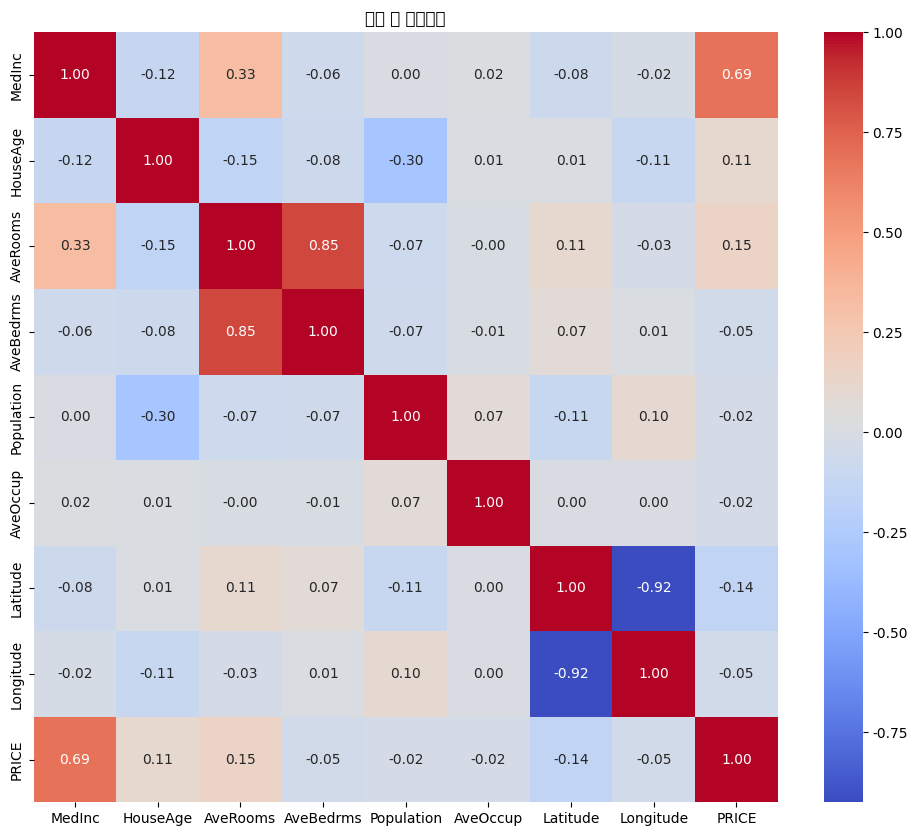

In [6]:
# 상관관계 분석
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('특성 간 상관관계')
plt.show()

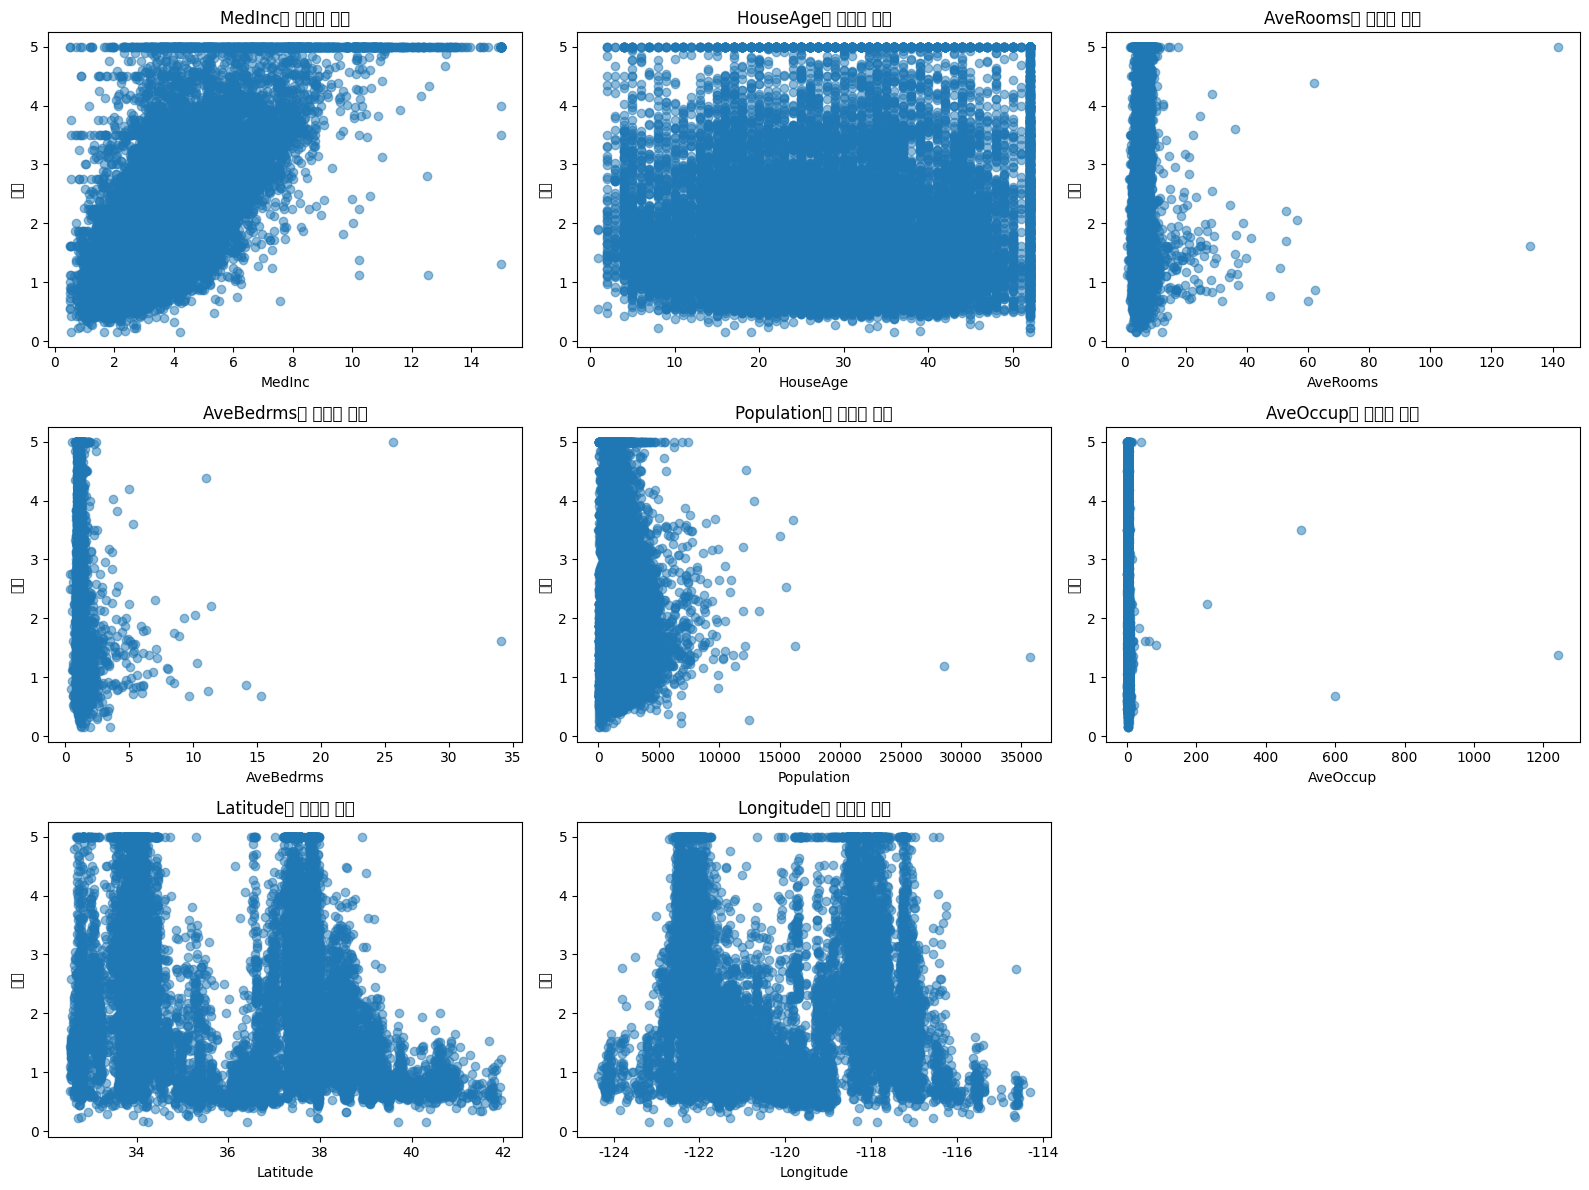

In [7]:
# 주요 특성과 타겟 변수 간의 산점도
plt.figure(figsize=(16, 12))

for i, feature in enumerate(housing.feature_names):
    plt.subplot(3, 3, i+1)
    plt.scatter(df[feature], df['PRICE'], alpha=0.5)
    plt.title(f'{feature}와 집값의 관계')
    plt.xlabel(feature)
    plt.ylabel('집값')

plt.tight_layout()
plt.show()

## 4. 데이터 전처리

In [8]:
# 특성(X)과 타겟(y) 분리
X = df.drop('PRICE', axis=1)
y = df['PRICE']

# 훈련 세트와 테스트 세트 분리 (80% 훈련, 20% 테스트)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"훈련 데이터 크기: {X_train.shape}")
print(f"테스트 데이터 크기: {X_test.shape}")

훈련 데이터 크기: (16512, 8)
테스트 데이터 크기: (4128, 8)


In [9]:
# 특성 스케일링 (표준화)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 스케일링 전후 비교
print("스케일링 전 훈련 데이터 처음 5개 샘플:")
print(X_train.iloc[:5])
print("\n스케일링 후 훈련 데이터 처음 5개 샘플:")
print(pd.DataFrame(X_train_scaled[:5], columns=X_train.columns))

스케일링 전 훈련 데이터 처음 5개 샘플:
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
14196  3.2596      33.0  5.017657   1.006421      2300.0  3.691814     32.71   
8267   3.8125      49.0  4.473545   1.041005      1314.0  1.738095     33.77   
17445  4.1563       4.0  5.645833   0.985119       915.0  2.723214     34.66   
14265  1.9425      36.0  4.002817   1.033803      1418.0  3.994366     32.69   
2271   3.5542      43.0  6.268421   1.134211       874.0  2.300000     36.78   

       Longitude  
14196    -117.03  
8267     -118.16  
17445    -120.48  
14265    -117.11  
2271     -119.80  

스케일링 후 훈련 데이터 처음 5개 샘플:
     MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0 -0.326196  0.348490 -0.174916  -0.208365    0.768276  0.051376 -1.372811   
1 -0.035843  1.618118 -0.402835  -0.128530   -0.098901 -0.117362 -0.876696   
2  0.144701 -1.952710  0.088216  -0.257538   -0.449818 -0.032280 -0.460146   
3 -1.017864  0.586545 -0.600015  -0.145156  

## 5. 선형 회귀 모델 구축 및 훈련

In [10]:
# 선형 회귀 모델 초기화
model = LinearRegression()

# 모델 훈련 (스케일링된 데이터 사용)
model.fit(X_train_scaled, y_train)

# 모델 계수 확인
print("절편(Intercept):", model.intercept_)
print("\n계수(Coefficients):")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.4f}")

절편(Intercept): 2.0719469373788777

계수(Coefficients):
MedInc: 0.8544
HouseAge: 0.1225
AveRooms: -0.2944
AveBedrms: 0.3393
Population: -0.0023
AveOccup: -0.0408
Latitude: -0.8969
Longitude: -0.8698


## 6. 모델 평가

In [11]:
# 훈련 세트에 대한 예측
y_train_pred = model.predict(X_train_scaled)

# 테스트 세트에 대한 예측
y_test_pred = model.predict(X_test_scaled)

# 평가 지표 계산
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

print("훈련 세트 성능:")
print(f"MSE: {train_mse:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print(f"R²: {train_r2:.4f}")

print("\n테스트 세트 성능:")
print(f"MSE: {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R²: {test_r2:.4f}")

훈련 세트 성능:
MSE: 0.5179
RMSE: 0.7197
R²: 0.6126

테스트 세트 성능:
MSE: 0.5559
RMSE: 0.7456
R²: 0.5758


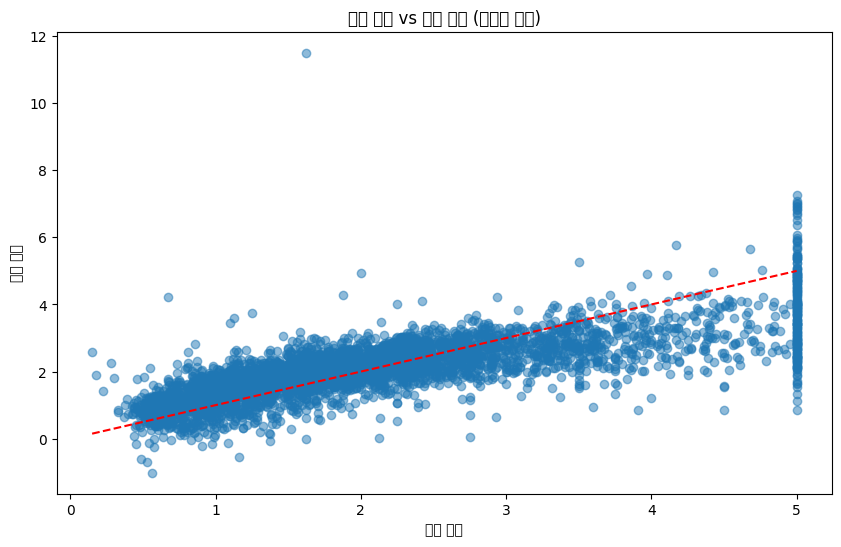

In [12]:
# 실제값과 예측값 비교 (테스트 세트)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('실제 집값')
plt.ylabel('예측 집값')
plt.title('실제 집값 vs 예측 집값 (테스트 세트)')
plt.show()

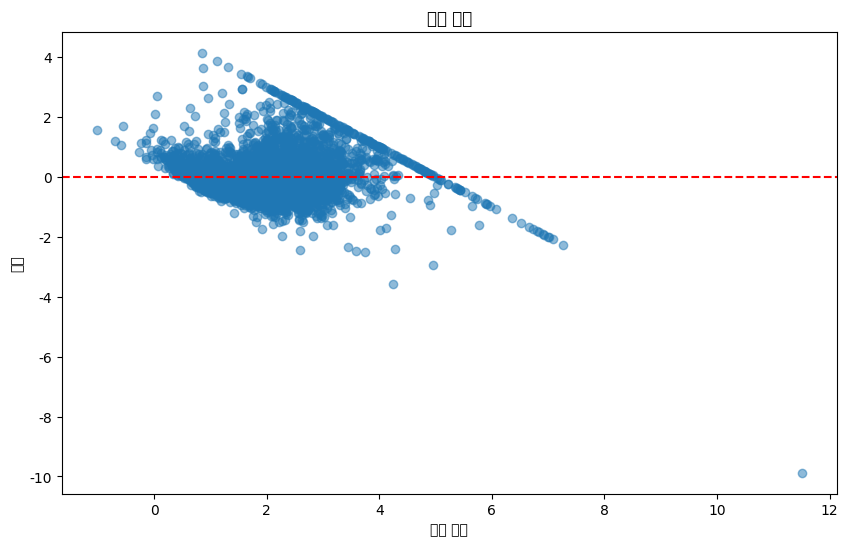

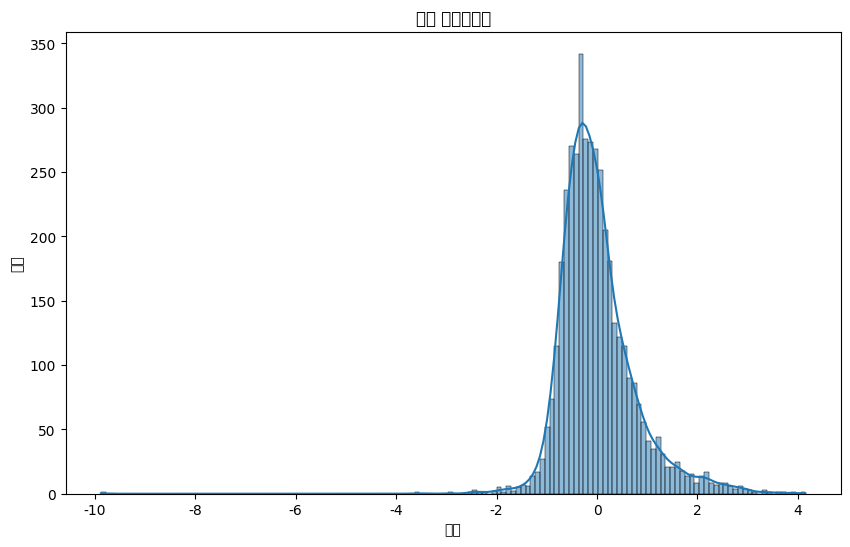

In [13]:
# 잔차(오차) 분석
residuals = y_test - y_test_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_test_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('예측 집값')
plt.ylabel('잔차')
plt.title('잔차 분포')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.xlabel('잔차')
plt.ylabel('빈도')
plt.title('잔차 히스토그램')
plt.show()

## 7. 특성 중요도 분석

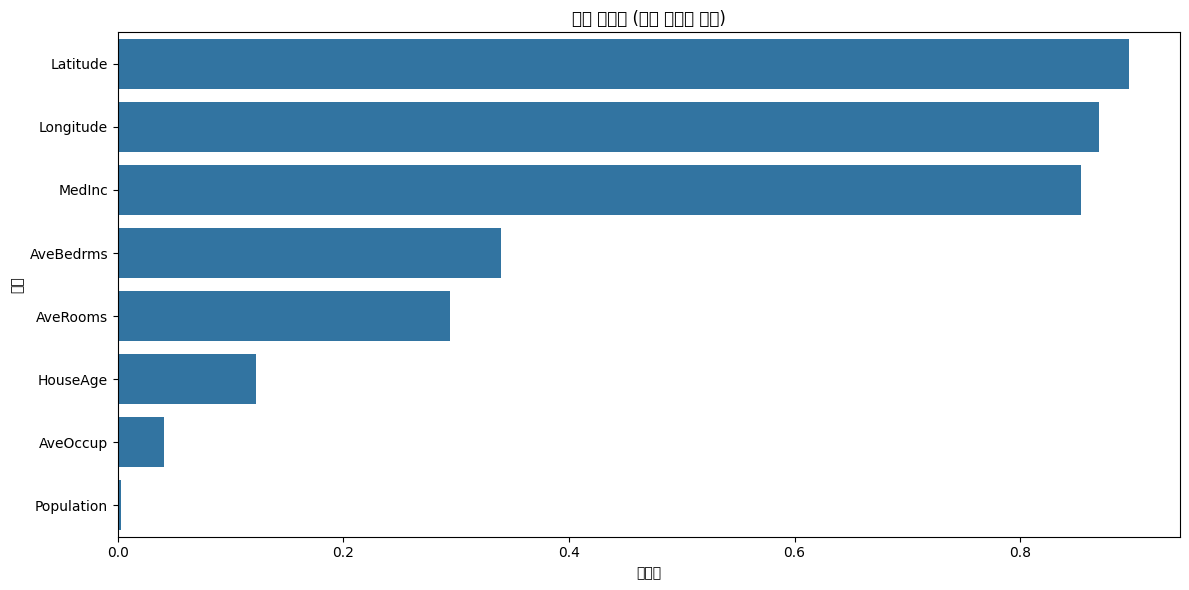

In [14]:
# 특성 중요도 (계수의 절대값 기준)
feature_importance = pd.DataFrame({
    '특성': X.columns,
    '중요도': np.abs(model.coef_)
})

feature_importance = feature_importance.sort_values('중요도', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='중요도', y='특성', data=feature_importance)
plt.title('특성 중요도 (계수 절대값 기준)')
plt.tight_layout()
plt.show()

## 8. 새로운 데이터에 대한 예측

In [15]:
# 새로운 주택 데이터 샘플 생성
new_house = pd.DataFrame({
    'MedInc': [6.0],          # 중간 소득
    'HouseAge': [30.0],       # 주택 연령
    'AveRooms': [6.0],        # 평균 방 수
    'AveBedrms': [1.0],       # 평균 침실 수
    'Population': [2000.0],   # 인구
    'AveOccup': [3.0],        # 평균 거주자 수
    'Latitude': [37.5],       # 위도
    'Longitude': [-122.0]     # 경도
})

# 새 데이터 스케일링
new_house_scaled = scaler.transform(new_house)

# 예측
predicted_price = model.predict(new_house_scaled)[0]
print(f"예측된 집값: ${predicted_price*100000:.2f}")

예측된 집값: $315923.18


## 9. 결론 및 요약

이 노트북에서는 선형 회귀를 사용하여 캘리포니아 주택 가격을 예측하는 모델을 구축했습니다. 주요 단계는 다음과 같습니다:

1. 데이터 로드 및 탐색: 캘리포니아 주택 데이터셋을 로드하고 기본 특성을 확인했습니다.
2. 데이터 시각화 및 분석: 타겟 변수의 분포와 특성 간의 상관관계를 시각화했습니다.
3. 데이터 전처리: 특성과 타겟을 분리하고, 훈련/테스트 세트로 나누었으며, 특성 스케일링을 수행했습니다.
4. 모델 구축 및 훈련: 선형 회귀 모델을 초기화하고 훈련 데이터로 학습시켰습니다.
5. 모델 평가: MSE, RMSE, R² 등의 지표를 사용하여 모델 성능을 평가했습니다.
6. 특성 중요도 분석: 각 특성이 예측에 미치는 영향을 분석했습니다.
7. 새로운 데이터에 대한 예측: 학습된 모델을 사용하여 새로운 주택 데이터에 대한 가격을 예측했습니다.

이 모델은 테스트 세트에서 약 0.6의 R² 점수를 보여주었으며, 이는 모델이 타겟 변수 분산의 약 60%를 설명할 수 있음을 의미합니다. 더 복잡한 모델(예: 랜덤 포레스트, 그래디언트 부스팅 등)을 사용하면 예측 성능을 더 향상시킬 수 있을 것입니다.